# Imbalanced Data

Data where one label is much more frequent than the other

***Training a classifier on imbalanced data***

Step 1:
    - tune hyperparameters using (eg grid search)
    - a *threshold-independent metric*: "average precision" or "area under roc curve"
Step 2:
    - adjust threshold based on your chosen metric
        - accuracy
        - precision
        - recall
        - custom metric
        ...
        - balanced accuracy
        
Balanced accuracy = $\frac{1}{2}\left(\frac{\text{TP}}{\text{TN}+\text{TN}}+\frac{\text{TN}}{\text{TN}+\text{FP}}\right)$

recall: If the actual label is $1$, how often is the prediction correct?

specificity: If the actual label is $0$, how often is the prediction correct?

Balanced accuracy takes the average of these two values. If balanced accuracy is close to $1$, the classifier performs well on both classes.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# model evaluation
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split

# feature preprocessing
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [3]:
# load adult census data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/adult_census.csv'
data = pd.read_csv(url)

In [4]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,label
0,2,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K
1,3,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,2,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States,<=50K
3,3,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States,<=50K
4,1,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38319,2,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,2,United-States,<=50K
38320,4,NaN,321403.0,HS-grad,9.0,Widowed,NaN,Other-relative,Black,Male,0,0,2,United-States,<=50K
38321,2,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,3,United-States,<=50K
38322,2,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,2,0,2,United-States,<=50K


In [7]:
top_country = data['native-country'].value_counts().head(15).index.to_list()

In [8]:
data.loc[~data['native-country'].isin(top_country), 'native-country'] = 'other'

In [9]:
data['native-country'].value_counts()

United-States         34214
other                  1639
Mexico                  909
Philippines             220
Puerto-Rico             166
Germany                 155
El-Salvador             145
Canada                  125
Cuba                    109
Dominican-Republic       99
India                    98
South                    95
Jamaica                  93
China                    89
Guatemala                85
England                  83
Name: native-country, dtype: int64

In [10]:
data.head(1)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,label
0,2,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K


In [25]:
# classification pipleline
num_features = ['age','education-num','capitalgain','capitalloss','hoursperweek']
cat_features = ['workclass', 'marital-status', 'occupation','relationship','race','sex','native-country']

In [26]:
num_processor = Pipeline(steps=[
    ('scale', MinMaxScaler()),
    ('impute', SimpleImputer(strategy='mean'))
])

cat_processor = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

feature_processor = ColumnTransformer(transformers = [
    ('num_processor', num_processor, num_features),
    ('cat', cat_processor, cat_features)
])

feature_processor

ColumnTransformer(transformers=[('num_processor',
                                 Pipeline(steps=[('scale', MinMaxScaler()),
                                                 ('impute', SimpleImputer())]),
                                 ['age', 'education-num', 'capitalgain',
                                  'capitalloss', 'hoursperweek']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'race', 'sex',
                                  'native-country'])])

In [27]:
from sklearn.preprocessing import PolynomialFeatures

In [31]:
pipe_clf = Pipeline(steps=[
    ('processor', feature_processor),
    ('poly_features', PolynomialFeatures(degree=1)),
    ('clf', LogisticRegression(max_iter=2000))
])
pipe_clf

Pipeline(steps=[('processor',
                 ColumnTransformer(transformers=[('num_processor',
                                                  Pipeline(steps=[('scale',
                                                                   MinMaxScaler()),
                                                                  ('impute',
                                                                   SimpleImputer())]),
                                                  ['age', 'education-num',
                                                   'capitalgain', 'capitalloss',
                                                   'hoursperweek']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('poly_features', PolynomialFeatures(degree=1)),
                ('clf', LogisticRegression(max_iter=2000))])

In [32]:
X = data[num_features+cat_features]
y = data.label
X_train,X_test,y_train,y_test = train_test_split(X,y)

In [33]:
pipe_clf.fit(X_train,y_train)
y_test_pred = pipe_clf.predict(X_test)

In [34]:
accuracy_score(y_test,y_test_pred)

0.974637302995512

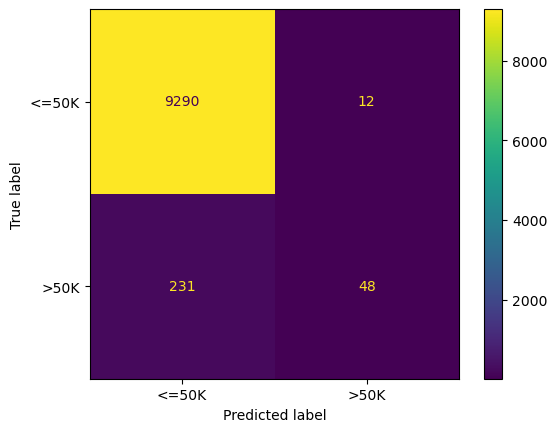

In [35]:
# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred)

 The model predicts the majority label very frequently, but is highly inaccurate on the minority label

In [36]:
param_dic = {
    'poly_features__degree' : [1,2]
}
grid = GridSearchCV(pipe_clf,
                   param_dic,
                   cv=10,
                   scoring='average_precision',
                    n_jobs=-1
                   ) # javi likes this metric for imbalanced data

grid.fit(X_train,y_train)

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('processor',
                                        ColumnTransformer(transformers=[('num_processor',
                                                                         Pipeline(steps=[('scale',
                                                                                          MinMaxScaler()),
                                                                                         ('impute',
                                                                                          SimpleImputer())]),
                                                                         ['age',
                                                                          'education-num',
                                                                          'capitalgain',
                                                                          'capitalloss',
                                                                          'hoursperweek']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encode',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['workclass',
                                                                          'marital-status',
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'sex',
                                                                          'native-country'])])),
                                       ('poly_features',
                                        PolynomialFeatures(degree=1)),
                                       ('clf',
                                        LogisticRegression(max_iter=2000))]),
             n_jobs=-1, param_grid={'poly_features__degree': [1, 2]},
             scoring='average_precision')

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 234, in __call__
    return self._score(
  File "/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 399, in _score
    return self._sign * self._score_func(y, y_pred, **self._kwargs)
  File "/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py", line 227, in average_precision_score
    raise ValueError(
ValueError: pos_label=1 is not a valid label. It should be one of ['<=50K', '>50K']

 

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 234, in __call__
    return self._score(
  File "/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 399, in _score
    return self._sign * self._score_func(y, y_pred, **self._kwargs)
  File "/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py", line 227, in average_precision_score
    raise ValueError(
ValueError: pos_label=1 is not a valid label. It should be one of ['<=50K', '>50K']

 